In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import gaussian_kde

In [3]:
df = pd.read_csv('NZCities.txt', sep=' ', skiprows=1)
df

,City,Population,Distance,Region
0,Picton,4.3,0,Nelson-Marlborough
1,Blenheim,28.2,27,Nelson-Marlborough
2,Kaikōura,2.3,156,Canterbury
3,Christchurch,381.0,336,Canterbury
4,Ashburton,34.8,416,Canterbury
5,Dunedin,128.8,691,Otago
6,Milton,2.1,745,Otago
7,Gore,12.8,842,Southland
8,Invercargill,57.1,895,Southland
9,Bluff,1.8,918,Southland


In [4]:
pop = df['Population'].values
dist = df['Distance'].values

## a)

In [5]:
data = []
for d, p in zip(dist, pop*10):
    p = int(p)
    print(p, d)
    array = np.ones(p)*d
    data.append(array)
data = np.concatenate(data)
data

43 0
282 27
23 156
3810 336
348 416
1288 691
21 745
128 842
571 895
18 918


array([  0.,   0.,   0., ..., 918., 918., 918.], shape=(6532,))

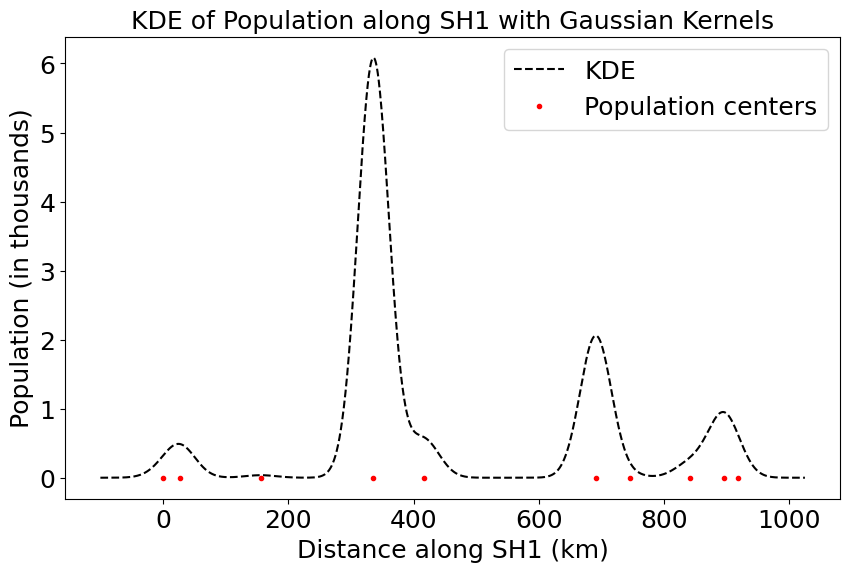

In [119]:
xvals = np.linspace(-100, 1025, 10000)
pop_kde = gaussian_kde(data, bw_method=25/np.std(data, ddof=1))
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(xvals, pop_kde(xvals)*np.sum(pop), 'k--', label='KDE')
ax.plot(dist, np.zeros_like(dist), 'r.', label = 'Population centers')
ax.set_xlabel('Distance along SH1 (km)', fontsize=18)
ax.set_ylabel('Population (in thousands)', fontsize=18)
ax.set_title('KDE of Population along SH1 with Gaussian Kernels', fontsize=18)
ax.tick_params(axis='both', which='major', labelsize=18)
ax.legend(fontsize=18)
fig.savefig("3a.pdf");

In [86]:
from scipy.integrate import quad
print(f"Normalization check for Gaussian KDE (likelihood). Area under graoh is {quad(lambda t: pop_kde(t), -100, 1025)[0]}")

Normalization check for Gaussian KDE (likelihood). Area under graoh is 0.9999997489004107


In [ ]:

N1 = quad(lambda t: pop_kde(t)*np.sum(pop), 405, 430)[0]
print(f"The total population estimate from 405 km to 430 km along SH1 is {N1:.1f} thousand")

The total population estimate from 405 km to 430 km along SH1 is 14.4 thousand


## b)

The assignment explicitly states "For distances along SH1 the following applies". Therefor the starting range has been taken as 0 instead of -100 which was used for plotting in a).

In [65]:
ranges = np.array([0, 91, 557, 823, 1025])
densities = np.array([5.5, 5.8, 6, 1.9])
regions = np.array(['Nelson-Marlborough', 'Canterbury', 'Otago', 'Southland'])
print(regions)

for i, density in enumerate(densities):
    Npop = quad(lambda t: pop_kde(t)*np.sum(pop), ranges[i], ranges[i+1])[0]
    Necars = Npop*density
    print(f'Using the population KDE there are {Necars:.0f} e-cars in the {regions[i]} region')

['Nelson-Marlborough' 'Canterbury' 'Otago' 'Southland']
Using the population KDE there are 144 e-cars in the Nelson-Marlborough region
Using the population KDE there are 2426 e-cars in the Canterbury region
Using the population KDE there are 803 e-cars in the Otago region
Using the population KDE there are 131 e-cars in the Southland region


## c)

In [47]:
reg = df['Region'].values
ecarpop = np.zeros(len(pop), dtype=int)
for i in range(len(ecarpop)):
    idx = np.where(reg[i] == regions)[0][0]
    ecarpop[i] = np.round(pop[i]*densities[idx],0)
print(ecarpop)
print(np.sum(ecarpop))

[  24  155   13 2210  202  773   13   24  108    3]
3525


In [48]:
def KDE_Epanechnikov(x, data, h):
    N = len(data)
    u = (x-data)/h
    K = np.zeros(N)
    K[np.abs(u)<=1]=0.75*(1-u[np.abs(u)<=1]**2)/h
    return np.sum(K)/N

In [60]:
data2 = []
for d, p in zip(dist, ecarpop):
    print(p, d)
    array = np.ones(p)*d
    data2.append(array)
data2 = np.concatenate(data2)
data2

24 0
155 27
13 156
2210 336
202 416
773 691
13 745
24 842
108 895
3 918


array([  0.,   0.,   0., ..., 918., 918., 918.], shape=(3525,))

Normalization check for Epanechnikov KDE. Area under graph is 0.9999982103659985


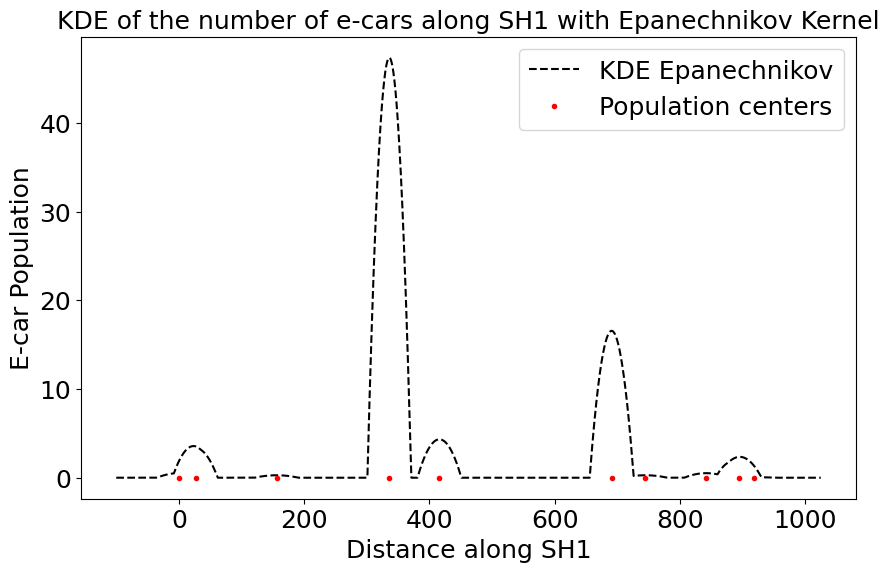

In [129]:
xvals = np.linspace(-100, 1025, 5000)
yvals = np.zeros_like(xvals)
Necarpop = np.sum(ecarpop)
for i, x in enumerate(xvals):
    yvals[i] = KDE_Epanechnikov(x, data2, 35) 
    
dx = xvals[1] - xvals[0]  
print(f"Normalization check for Epanechnikov KDE. Area under graph is {np.sum(yvals)*dx}")
    
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(xvals, yvals*Necarpop, 'k--', label='KDE Epanechnikov')
ax.plot(dist, np.zeros_like(dist), 'r.', label = 'Population centers')
ax.set_xlabel('Distance along SH1', fontsize=18)
ax.set_ylabel('E-car Population', fontsize=18)
ax.set_title('KDE of the number of e-cars along SH1 with Epanechnikov Kernel', fontsize=18)
ax.tick_params(axis='both', which='major', labelsize=18)
ax.legend(fontsize=18);
fig.savefig("3c.pdf");

In [66]:
distNew = np.array([100, 200, 300, 400, 500, 600, 700, 800])
ecarpopNew = np.array([12, 5, 178, 113, 42, 67, 23, 2])

data3 = []
for d, p in zip(distNew, ecarpopNew):
    print(p, d)
    array = np.ones(p)*d
    data3.append(array)
data3 = np.concatenate(data3)
# print(len(data3), '\n', data3)

12 100
5 200
178 300
113 400
42 500
67 600
23 700
2 800


Normalization check for Gaussian KDE (likelihood). Area under graph is 0.9999991247599442


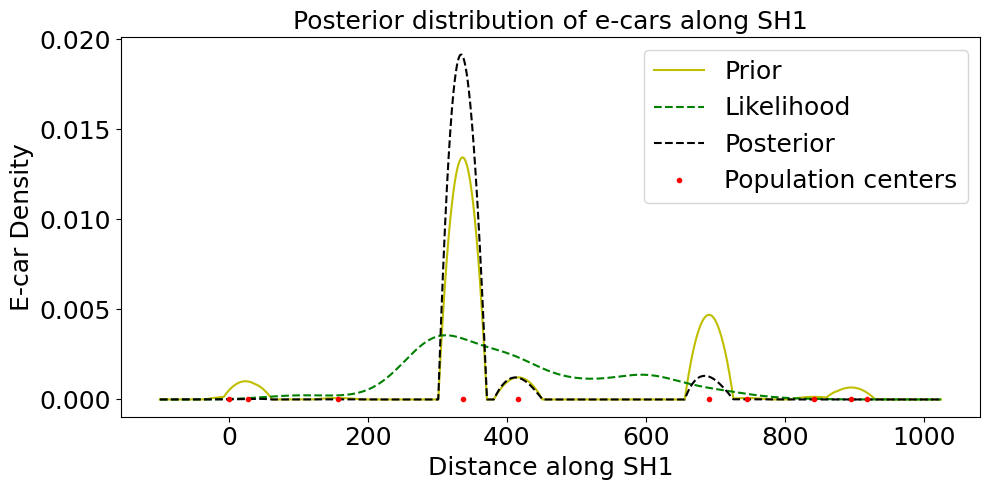

In [137]:
ecarKDE = gaussian_kde(data3, bw_method=50/np.std(data3, ddof=1))
print(f"Normalization check for Gaussian KDE (likelihood). Area under graph is {quad(lambda t: ecarKDE(t), -100, 1025)[0]}")

xvals = np.linspace(-100, 1025, 5000)
dx = xvals[1] - xvals[0]
yvals2 = ecarKDE(xvals)

posterior = yvals*yvals2
Npost = np.sum(posterior)*dx
posterior /= Npost

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(xvals, yvals, 'y', label='Prior')
ax.plot(xvals, yvals2, 'g--', label='Likelihood')
ax.plot(xvals, posterior, 'k--', label='Posterior')
ax.plot(dist, np.zeros_like(dist), 'r.', label = 'Population centers')
ax.set_xlabel('Distance along SH1', fontsize=18)
ax.set_ylabel('E-car Density', fontsize=18)
ax.set_title('Posterior distribution of e-cars along SH1', fontsize=18)
ax.tick_params(axis='both', which='major', labelsize=18)
ax.legend(fontsize=18)
plt.tight_layout()
fig.savefig("3c_3.pdf");

In [138]:
frac = np.sum(posterior[(400<=xvals) & (xvals<=700)])*dx
print(f"Using the posterior, the fraction of e-cars in New Zealand alongSH1 between 400 km to 700 km is {frac:.4f}")

Using the posterior, the fraction of e-cars in New Zealand alongSH1 between 400 km to 700 km is 0.0890
